# Stochastic Gradient Descent
You should build an end-to-end machine learning pipeline using a stochastic gradient descent model. In particular, you should do the following:
- Load the `mnist` dataset using [Pandas](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html). You can find this dataset in the datasets folder.
- Split the dataset into training and test sets using [Scikit-Learn](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html).
- Build an end-to-end machine learning pipeline, including a [stochastic gradient descent](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html) model.
- Optimize your pipeline by validating your design decisions.
- Test the best pipeline on the test set and report various [evaluation metrics](https://scikit-learn.org/0.15/modules/model_evaluation.html).  
- Check the documentation to identify the most important hyperparameters, attributes, and methods of the model. Use them in practice.

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/m-mahdavi/teaching/refs/heads/main/datasets/mnist.csv")
display(df.head())

,id,class,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,31953,5,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,34452,8,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,60897,5,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,36953,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1981,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df_train, df_test = train_test_split(df, test_size=0.2)
print(f"Shape of original data:- {df.shape}")
print(f"Shape of train data:- {df_train.shape}")
print(f"Shape of test data:- {df_test.shape}")

Shape of original data:- (4000, 786)
Shape of train data:- (3200, 786)
Shape of test data:- (800, 786)


In [4]:
display(df_train.isnull().sum())
display(df_train.describe())
display(df_train.info())

,0
id,0
class,0
pixel1,0
pixel2,0
pixel3,0
...,...
pixel780,0
pixel781,0
pixel782,0
pixel783,0


,id,class,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
count,3200.000000,3200.000000,3200.0,3200.0,3200.0,3200.0,3200.0,3200.0,3200.0,3200.0,...,3200.000000,3200.0,3200.000000,3200.000000,3200.0,3200.0,3200.0,3200.0,3200.0,3200.0
mean,34484.151875,4.446562,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.083125,0.0,0.016250,0.001875,0.0,0.0,0.0,0.0,0.0,0.0
std,20535.515030,2.888404,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.833721,0.0,0.919239,0.106066,0.0,0.0,0.0,0.0,0.0,0.0
min,17.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
25%,16629.750000,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
50%,34511.500000,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
75%,52183.500000,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
max,69998.000000,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,125.000000,0.0,52.000000,6.000000,0.0,0.0,0.0,0.0,0.0,0.0


<class 'pandas.core.frame.DataFrame'>
Index: 3200 entries, 1911 to 2562
Columns: 786 entries, id to pixel784
dtypes: int64(786)
memory usage: 19.2 MB


None

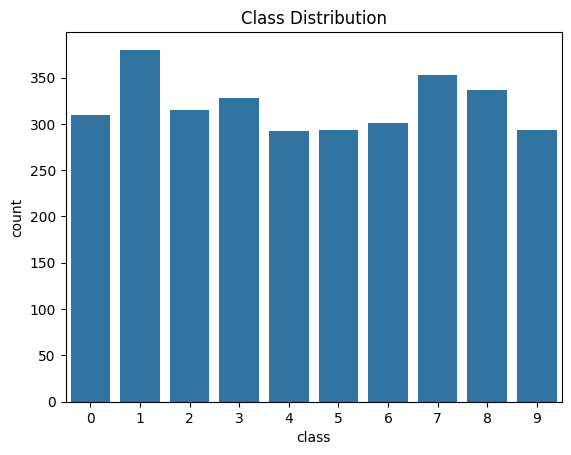

In [5]:
sns.countplot(x='class', data=df_train)
plt.title("Class Distribution")
plt.show()

In [6]:
x_train = df_train.drop(["class", "id"], axis=1,)
y_train = df_train["class"]

x_test = df_test.drop(["class", "id"], axis=1)
y_test = df_test["class"]

print(f"Shape of x_train:- {x_train.shape}")
print(f"Shape of x_test:- {x_test.shape}")
print(f"Shape of y_train:- {y_train.shape}")
print(f"Shape of y_test:- {y_test.shape}")

Shape of x_train:- (3200, 784)
Shape of x_test:- (800, 784)
Shape of y_train:- (3200,)
Shape of y_test:- (800,)


In [9]:
numerical_attributes = x_train.select_dtypes(include=['int64']).columns

ct = ColumnTransformer([("scaling", StandardScaler(), numerical_attributes)])
ct.fit(x_train)

x_train = ct.transform(x_train)
x_test = ct.transform(x_test)

Shape of x_train:- (3200, 784)
Shape of x_test:- (800, 784)


In [14]:
param_grid_sgd = {
    'loss': ['hinge', 'log', 'modified_huber', 'squared_hinge', 'perceptron'],
    'penalty': ['l1', 'l2', 'elasticnet'],
    'alpha': [0.0001, 0.001, 0.01],
    'max_iter': [500, 1000],
}

In [ ]:
sgd_classifier = SGDClassifier()
grid_search_sgd = GridSearchCV(estimator=sgd_classifier, param_grid=param_grid_sgd, cv=5, scoring='accuracy')
grid_search_sgd.fit(x_train, y_train)

print("Best hyperparameters:", grid_search_sgd.best_params_)
print("Best score:", grid_search_sgd.best_score_)

In [ ]:
best_sgd_model = grid_search_sgd.best_estimator_
y_pred = best_sgd_model.predict(x_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Confusion Matrix')
plt.show()